# Why `row_extra_quote0_col2.csv` loads 0 rows

The injected quote makes the **header** strict-invalid. With `strict_mode=true`, DuckDB silently returns 0 rows (0 rejects, no error) even though the header is skipped.

In [1]:
import duckdb

F = "/home/robin/offsite/pollock-offsite/data/small_sample/csv/row_extra_quote0_col2.csv"
COLS = "{" + ", ".join(f"'_c{i}': 'VARCHAR'" for i in range(9)) + "}"

def load(path=F, escape='"', strict=True):
    q = (f"SELECT count(*) FROM read_csv(?, auto_detect=false, columns={COLS}, "
         "delim=',', quote='\"', escape=?, header=false, skip=1, "
         "strict_mode=?, null_padding=true)")
    return duckdb.execute(q, [path, escape, strict]).fetchone()[0]

for esc in ('"', ''):
    for strict in (True, False):
        print(f"escape={esc!r:4} strict={strict!s:5} -> {load(escape=esc, strict=strict)} rows")

escape='"'  strict=True  -> 0 rows
escape='"'  strict=False -> 81 rows
escape=''   strict=True  -> 0 rows
escape=''   strict=False -> 83 rows


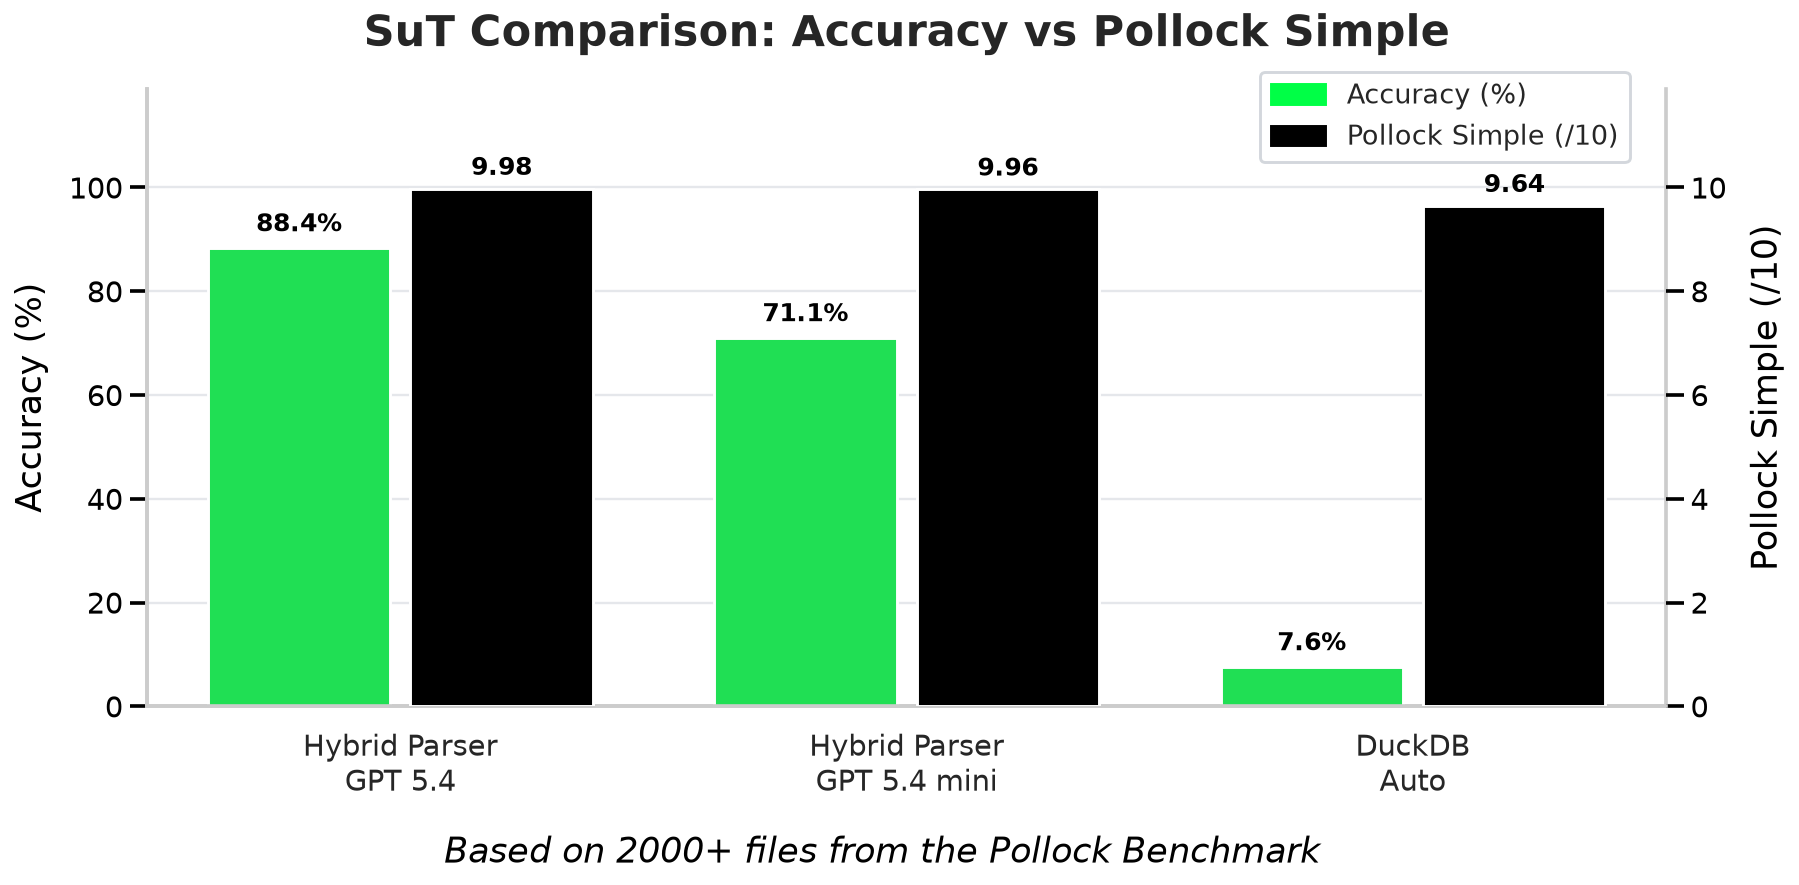

In [47]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

df = pd.DataFrame({
    "SuT": [
        "Hybrid Parser\nGPT 5.4",
        "Hybrid Parser\nGPT 5.4 mini",
        "DuckDB\nAuto"
    ],
    "accuracy_pct": [88.3893, 71.0607, 7.6386],
    "pollock_simple": [9.975212, 9.962150, 9.645]
})

sns.set_theme(style="whitegrid", context="talk")

fig, ax1 = plt.subplots(figsize=(14, 7), dpi=140)
ax2 = ax1.twinx()

# Make the second axis background transparent so it doesn't cover the first bars
ax2.patch.set_alpha(0)

accuracy_color = "#00FF46"   # cool cyan
pollock_color = "#000"    # cool blue
label_color = "#000"      # dark slate

# Accuracy bars on left axis
sns.barplot(
    data=df,
    x="SuT",
    y="accuracy_pct",
    ax=ax1,
    color=accuracy_color,
    width=0.36,
    zorder=3
)

# Pollock bars on right axis
sns.barplot(
    data=df,
    x="SuT",
    y="pollock_simple",
    ax=ax2,
    color=pollock_color,
    width=0.36,
    zorder=3
)

# Move bars side-by-side instead of overlapping
for bar in ax1.patches:
    bar.set_x(bar.get_x() - 0.20)

for bar in ax2.patches:
    bar.set_x(bar.get_x() + 0.20)

# Axes
ax1.set_ylim(0, 105)
ax2.set_ylim(0, 10.8)

ax1.set_ylabel("Accuracy (%)", color='#000', fontsize=18, labelpad=10)
ax2.set_ylabel("Pollock Simple (/10)", color='#000', fontsize=18, labelpad=12)

ax1.tick_params(axis="y", colors='#000', labelsize=15)
ax2.tick_params(axis="y", colors='#000', labelsize=15)
ax1.tick_params(axis="x", labelsize=15)

ax1.set_xlabel("")
ax1.set_title(
    "SuT Comparison: Accuracy vs Pollock Simple",
    fontsize=22,
    weight="bold",
    pad=22
)

# Grid behind bars, not through them
ax1.set_axisbelow(True)
ax1.grid(axis="y", color="#E5E7EB", linewidth=1.2, zorder=0)
ax1.grid(axis="x", visible=False)
ax2.grid(False)

# Bar labels: dark, larger, readable
for bar in ax1.patches:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width() / 2,
        height + 2,
        f"{height:.1f}%",
        ha="center",
        va="bottom",
        fontsize=13,
        weight="bold",
        color=label_color,
        zorder=5
    )

for bar in ax2.patches:
    height = bar.get_height()
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.15,
        f"{height:.2f}",
        ha="center",
        va="bottom",
        fontsize=13,
        weight="bold",
        color=label_color,
        zorder=5
    )

# Legend
legend_handles = [
    plt.Rectangle((0, 0), 1, 1, color=accuracy_color),
    plt.Rectangle((0, 0), 1, 1, color=pollock_color),
]

ax1.legend(
    legend_handles,
    ["Accuracy (%)", "Pollock Simple (/10)"],
    loc="upper right",
    bbox_to_anchor=(0.985, 1.05),
    ncol=1,
    frameon=True,
    facecolor="white",
    edgecolor="#D1D5DB",
    framealpha=0.95,
    fontsize=14
)

sns.despine(ax=ax1, right=False)
sns.despine(ax=ax2, left=False)

fig.subplots_adjust(bottom=0.25, top=0.88)

ax1.set_ylim(0, 119)
ax2.set_ylim(0, 11.9)

fig.text(
    0.5, 0.1,
    "Based on 2000+ files from the Pollock Benchmark",
    ha="center",
    va="center",
    fontsize=18,
    color="#000",
    style="italic"
)

plt.show()

In [2]:
# Fix ONLY the header's extra quote -> all rows load, even under strict mode
fixed = "/tmp/fixed_header.csv"
body = open(F, "rb").read().split(b"\r\n", 1)[1]
open(fixed, "wb").write(b"DATE,TIME,Qty,PRODUCTID,Price,ProductType,ProductDescription,URL,Comments\r\n" + body)

print("fixed header, strict ->", load(path=fixed), "rows (expected 83)")

fixed header, strict -> 83 rows (expected 83)
